<a href="https://colab.research.google.com/github/PabloDuranL/Miprogresionypraticas/blob/main/Logistica_perceptron_mcs_SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [539]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [540]:
data=load_breast_cancer()

In [541]:
x=data.data
y=data.target

In [542]:
y[y == 0] = -1

In [543]:
df=pd.DataFrame(x, columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [544]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=123)

In [545]:
medias = x_train.mean(axis=0)
desv = x_train.std(axis=0)

x_train = (x_train - medias) / desv
x_test = (x_test - medias) / desv

In [546]:
w=np.zeros(x_train.shape[1])
b=0
ciclos=500
rate=0.2
historial=[]
costos=[]
for ciclo in range(ciclos):
  errores=0
  indices=np.random.permutation(len(x_train))
  for i in indices:
    xs=x_train[i]
    t=y_train[i]
    a=np.dot(w,xs)+b
    if a*t<=0:
      w=w+rate*t*xs
      b=b+rate*t
      errores+=1
      costo-=a*t
    else:
      pass
  historial.append(errores)

  costo=0
  for xs, t in zip(x_train, y_train):

        a = np.dot(w, xs) + b

        if a*t <= 0:

            costo += -a*t

  costos.append(costo)



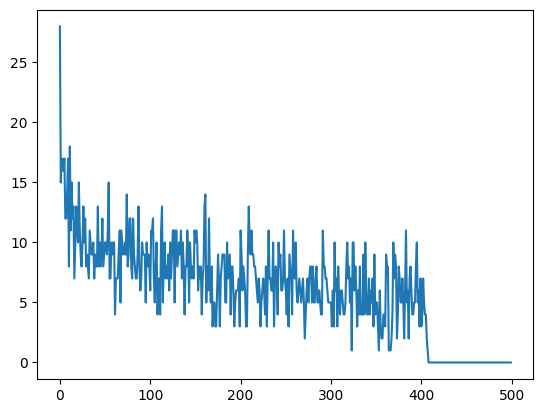

In [547]:
plt.plot(historial)

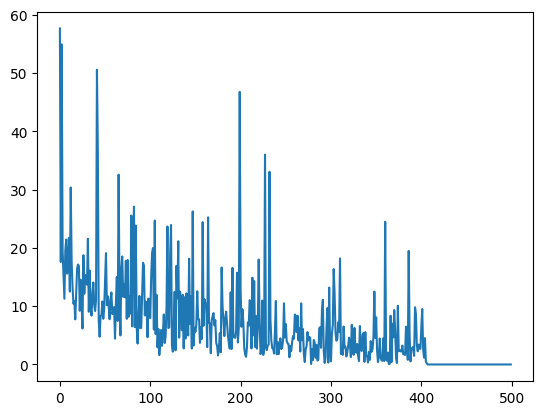

In [548]:
plt.plot(costos)

In [549]:
#PREDICCIONES
y_pred=np.dot(w,x_test.T)+b
accuracy_score(y_test,np.sign(y_pred))

0.9736842105263158

In [550]:
rendimiento=pd.DataFrame(classification_report(y_test,np.sign(y_pred), output_dict=True))
rendimiento

,-1,1,accuracy,macro avg,weighted avg
precision,0.975000,0.972973,0.973684,0.973986,0.973702
recall,0.951220,0.986301,0.973684,0.968760,0.973684
f1-score,0.962963,0.979592,0.973684,0.971277,0.973611
support,41.000000,73.000000,0.973684,114.000000,114.000000


In [551]:
print(np.unique(np.sign(y_pred)))

[-1.  1.]


In [552]:
print(np.bincount((y_train == 1).astype(int)))

[171 284]


In [553]:
print(np.linalg.norm(w))

32.80009556804332


Text(0.5, 1.0, 'Costo del perceptrón')

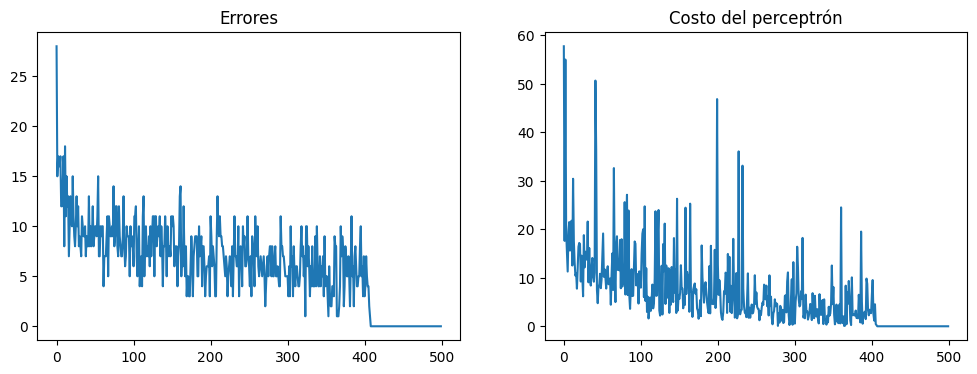

In [554]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(historial)
plt.title("Errores")

plt.subplot(1,2,2)
plt.plot(costos)
plt.title("Costo del perceptrón")

In [555]:
#MINIMOS CUADRADOS
X=np.hstack((x_train, np.ones((x_train.shape[0], 1))))
phi=np.linalg.inv(X.T@X)@X.T@y_train
X_test=np.hstack((x_test, np.ones((x_test.shape[0], 1))))
y_pmc=X_test@phi
accuracy_score(y_test,np.sign(y_pmc))
classification_report(y_test,np.sign(y_pmc))

'              precision    recall  f1-score   support\n\n          -1       1.00      0.93      0.96        41\n           1       0.96      1.00      0.98        73\n\n    accuracy                           0.97       114\n   macro avg       0.98      0.96      0.97       114\nweighted avg       0.97      0.97      0.97       114\n'

In [556]:
rendimiento=pd.DataFrame(classification_report(y_test,np.sign(y_pmc), output_dict=True))
rendimiento

,-1,1,accuracy,macro avg,weighted avg
precision,1.000000,0.960526,0.973684,0.980263,0.974723
recall,0.926829,1.000000,0.973684,0.963415,0.973684
f1-score,0.962025,0.979866,0.973684,0.970946,0.973449
support,41.000000,73.000000,0.973684,114.000000,114.000000


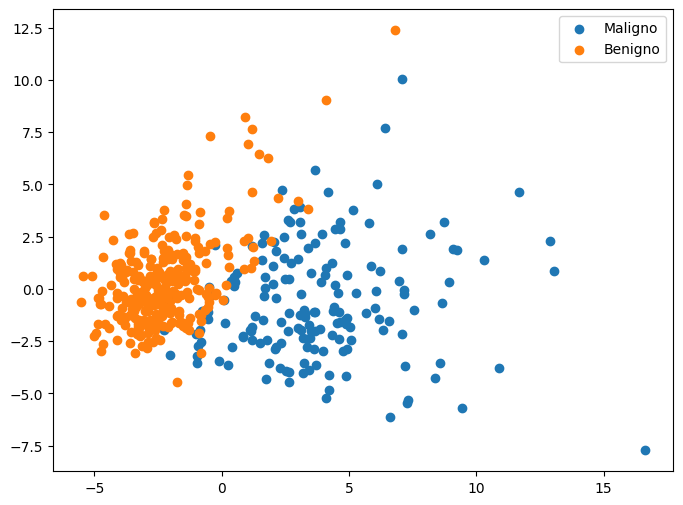

In [557]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_train)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[y_train==-1,0],
    X_pca[y_train==-1,1],
    label="Maligno"
)

plt.scatter(
    X_pca[y_train==1,0],
    X_pca[y_train==1,1],
    label="Benigno"
)

plt.legend()

In [558]:
#REGRESSION LOGISTICA MEDIANTE GRADIENTE ESTOCASTICO DESCENDIENTE
y[y==-1]=0
y_train[y_train==-1]=0
y_test[y_test==-1]=0

In [559]:
epoch=500
w=np.zeros(x_train.shape[1])
b=0
rate=0.1

maxllh=[]
for ciclos in range(epoch):
  llh=0
  indice=np.random.permutation(len(x_train))
  for i in indice:
    xs=x_train[i]
    t=y_train[i]
    y=1/(1+np.exp(-(np.dot(w,xs)+b)))
    y = np.clip(y, 1e-15, 1-1e-15)
    grad=(y-t)*xs
    w-=rate*grad
    b-=rate*(y-t)

  for xs, t in zip(x_train,y_train):
    z=np.dot(w,xs)+b
    s=1/(1+np.exp(-z))
    s=np.clip(s, 1e-15, 1-1e-15)
    llh+=t*np.log(s)+(1-t)*np.log(1-s)
  maxllh.append(llh)





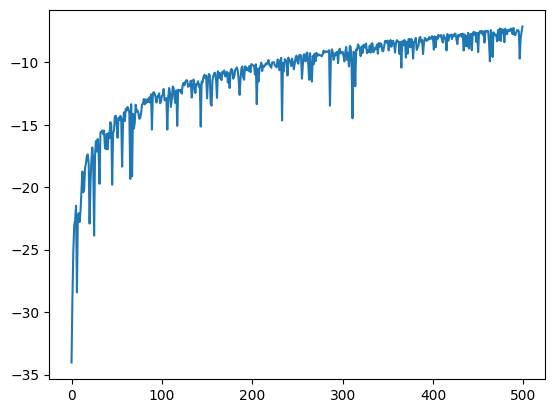

In [560]:
plt.plot(maxllh)

In [561]:
def indicadora(x):
  if x<=0.5:
    x=0
  if x>0.5:
    x=1


In [563]:
z = (w.dot(x_test.T) + b)
y_prob = 1 / (1 + np.exp(-z))
y_pred = (y_prob > 0.5).astype(int)
accuracy_score(y_test, y_pred)

0.9824561403508771

In [569]:
pd.DataFrame({'y real':y_test, 'y pred':y_pred,'probabilidad':np.round(y_prob,5)})

,y real,y pred,probabilidad
0,1,1,1.0
1,1,1,1.0
2,0,0,0.0
3,1,1,1.0
4,0,0,0.0
...,...,...,...
109,1,1,1.0
110,1,1,1.0
111,1,1,1.0
112,1,1,1.0
